# Wake Vision — MobileNetV3-Small
**Dataset:** [Wake Vision](https://anonymous/paper) (paper authors, see citation)
— binary classification: **person** vs **non-person**

**Model:** MobileNetV3-Small (ImageNet pre-trained, fine-tuned)

**Pipeline:** download via `tensorflow_datasets` → preprocess → two-phase training (head → fine-tune) → evaluation

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "src").is_dir())))
from src.paths import ROOT


## 1 — Imports and constants

In [7]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

SEED = 42
IMG_SIZE = 224          # MobileNetV3 is designed for 224×224
BATCH_SIZE = 64
NUM_CLASSES = 2         # person / non-person
GPU_ID = 1              # which GPU to use (0 or 1); None = all

USE_AUGMENTATION = False

tf.keras.utils.set_random_seed(SEED)

class_names = ["no_person", "person"]

print("TensorFlow:", tf.__version__)
print("TFDS:", tfds.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.20.0
TFDS: 4.9.9
NumPy: 2.4.2


## 2 — Check GPU and configure memory growth

In [ ]:
gpus = tf.config.list_physical_devices("GPU")
print("Available GPUs:", gpus)

if gpus:
    if GPU_ID is not None:
        chosen = gpus[GPU_ID]
        tf.config.set_visible_devices([chosen], "GPU")
        tf.config.experimental.set_memory_growth(chosen, True)
        print(f"✓ Using only GPU {GPU_ID}: {chosen.name}")
    else:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ Using all {len(gpus)} GPUs")
else:
    print("⚠ No GPU detected — training will run on CPU (much slower)")

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✓ Using only GPU 1: /physical_device:GPU:1


## 3 — Load Wake Vision via TFDS

Wake Vision has 3 splits:
- **train_quality** (~1.2M images) — curated version with lower labeling error
- **validation** (~18K images)
- **test** (~55K images)

⚠️ Images with `person == -1` in the test set belong to the "far distance" benchmark and should be filtered out for standard evaluation.

In [ ]:
from pathlib import Path
import shutil

DATA_DIR = "/anonymous/data"
WAKE_VERSION_DIR = Path(DATA_DIR) / "wake_vision" / "1.0.0"

# If a previous attempt failed, a partial cache folder may remain without dataset_info.json
if WAKE_VERSION_DIR.exists() and not (WAKE_VERSION_DIR / "dataset_info.json").exists():
    print(f"⚠ Partial cache detected at {WAKE_VERSION_DIR}. Removing...")
    shutil.rmtree(WAKE_VERSION_DIR)

# Dependency used by some TFDS builders/environments
try:
    import importlib_resources  # noqa: F401
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency: importlib_resources. Run `uv add importlib-resources` "
        "and restart the notebook kernel."
    ) from exc

# Download and loading Wake Vision (first time takes a while: ~365 GB)
ds_train, ds_val, ds_test = tfds.load(
    "wake_vision",
    split=["train_quality", "validation", "test"],
    data_dir=DATA_DIR,
    as_supervised=False,   # returns dicts with 'image' and 'person'
    shuffle_files=False,
)

# Filter examples with person == -1 from test ("far distance" benchmark)
ds_test = ds_test.filter(lambda x: x["person"] >= 0)

# Convert dict -> (image, label)
def _to_supervised(example):
    return example["image"], tf.cast(example["person"], tf.int64)

ds_train = ds_train.map(_to_supervised, num_parallel_calls=tf.data.AUTOTUNE)
ds_val   = ds_val.map(_to_supervised, num_parallel_calls=tf.data.AUTOTUNE)
ds_test  = ds_test.map(_to_supervised, num_parallel_calls=tf.data.AUTOTUNE)

# Count of examples per split
for name, ds in [("train", ds_train), ("val", ds_val), ("test", ds_test)]:
    n = ds.reduce(0, lambda acc, _: acc + 1).numpy()
    print(f"{name:>5s}: {n:>10,d} examples")

train:  1,248,230 examples
  val:     18,582 examples
 test:     55,762 examples


## 4 — Preprocessing and tf.data pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(image, label, training: bool):
    """uint8 [0,255] -> float32, resize, optional augmentation."""
    image = tf.cast(image, tf.float32)

    if training and USE_AUGMENTATION:
        # Simple augmentation for real-world images
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.2)
        image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
        image = tf.clip_by_value(image, 0.0, 255.0)

    # Resize to backbone input size
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), method="bilinear")

    return image, label


def make_ds(ds, training: bool):
    """Applies preprocess, shuffle, batch and prefetch."""
    if training:
        ds = ds.shuffle(10_000, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda im, lab: preprocess_image(im, lab, training),
        num_parallel_calls=AUTOTUNE,
    )
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_ds(ds_train, training=True)
val_ds   = make_ds(ds_val,   training=False)
test_ds  = make_ds(ds_test,  training=False)

# Check a sample
for images, labels in train_ds.take(1):
    print("Batch shape:", images.shape, images.dtype)
    print("Labels shape:", labels.shape, labels.dtype)
    print("Min/Max pixel:", float(images.numpy().min()), float(images.numpy().max()))
    print("Labels sample:", labels.numpy()[:10])

Batch shape: (64, 224, 224, 3) <dtype: 'float32'>
Labels shape: (64,) <dtype: 'int64'>
Min/Max pixel: 0.0 255.0
Labels amostra: [1 1 0 1 0 1 1 1 0 0]


2026-03-12 10:58:50.835196: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5 — Hyperparameters and training utilities

In [ ]:
from pathlib import Path
from tensorflow.keras import layers

INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# ---------- Training hyperparameters ----------
EPOCHS_HEAD = 40
EPOCHS_FINE = 20
HEAD_LR = 1e-3
FINE_LR = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
FINE_TUNE_RATIO = 0.8         # unfreeze the last 20% of backbone layers

CHECKPOINT_DIR = ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

KERAS_MODELS_DIR = ROOT / "keras_models"
KERAS_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Common callbacks ----------
base_callbacks = [
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        restore_best_weights=True,
        monitor="val_accuracy",
        mode="max",
        min_delta=1e-3,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=3,
        factor=0.5,
        min_lr=1e-6,
        monitor="val_loss",
        verbose=1,
    ),
]


# ---------- Utility functions ----------
def make_common_stem(preprocess_layer: tf.keras.layers.Layer):
    """Input + preprocess layer (plain layer, serializable)."""
    inputs = tf.keras.Input(shape=INPUT_SHAPE)
    x = preprocess_layer(inputs)
    return inputs, x


def make_sparse_ce_with_label_smoothing(label_smoothing: float):
    """Label smoothing for sparse (int) labels."""
    if not label_smoothing or label_smoothing <= 0.0:
        return tf.keras.losses.SparseCategoricalCrossentropy()

    cce = tf.keras.losses.CategoricalCrossentropy()

    def loss(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true = tf.one_hot(y_true, depth=NUM_CLASSES)
        y_true = y_true * (1.0 - label_smoothing) + (label_smoothing / NUM_CLASSES)
        return cce(y_true, y_pred)

    return loss


def make_optimizer(lr: float, weight_decay: float):
    """AdamW if available; otherwise Adam."""
    AdamW = getattr(tf.keras.optimizers, "AdamW", None)
    if AdamW is not None:
        return AdamW(learning_rate=lr, weight_decay=weight_decay)
    return tf.keras.optimizers.Adam(learning_rate=lr)


print("✓ Hyperparameters and utilities ready")

✓ Hyperparameters and utilities ready


## 6 — Build MobileNetV3-Small

In [8]:
from tensorflow.keras.applications import MobileNetV3Small


def build_mobilenetv3_small(num_classes: int = NUM_CLASSES, dropout: float = 0.2):
    """MobileNetV3-Small with a custom head for binary classification."""
    # Rescaling: [0,255] -> [-1, 1]
    preprocess = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess_mnv3")
    inputs, x = make_common_stem(preprocess)

    base = MobileNetV3Small(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_preprocessing=False,  # we already rescale above
    )
    base.trainable = False  # freeze backbone in phase 1

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="MobileNetV3Small_WakeVision")
    return model, base


mobilenet_model, mobilenet_base = build_mobilenetv3_small()
mobilenet_model.summary()

Model: "MobileNetV3Small_WakeVision"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_mnv3 (Rescaling)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         1,154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 940,274 (3.59 MB)

 Trainable params: 1,154 (4.51 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 7 — Training (frozen head → fine-tune)

In [ ]:
def train_head_and_finetune(
    model: tf.keras.Model,
    base: tf.keras.Model | None,
    model_tag: str,
    head_epochs: int = EPOCHS_HEAD,
    fine_epochs: int = EPOCHS_FINE,
    head_lr: float = HEAD_LR,
    fine_lr: float = FINE_LR,
    weight_decay: float = WEIGHT_DECAY,
    label_smoothing: float = LABEL_SMOOTHING,
    fine_tune_ratio: float = FINE_TUNE_RATIO,
):
    """Phase 1: train head (frozen backbone). Phase 2: partial fine-tune."""

    ckpt_path = CHECKPOINT_DIR / f"{model_tag.replace(' ', '_')}_best.weights.h5"
    ckpt_cb = tf.keras.callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )
    callbacks = base_callbacks + [ckpt_cb]

    loss_fn = make_sparse_ce_with_label_smoothing(label_smoothing)
    metrics = [
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2"),
    ]

    # ---------- Phase 1: Head ----------
    print(f"\n{'='*60}")
    print(f"[{model_tag}] Phase 1 — head training ({head_epochs} epochs)")
    print(f"{'='*60}")

    model.compile(
        optimizer=make_optimizer(head_lr, weight_decay),
        loss=loss_fn,
        metrics=metrics,
    )

    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=head_epochs,
        callbacks=callbacks,
    )

    # ---------- Phase 2: Fine-tune ----------
    history_ft = None
    if fine_epochs > 0:
        print(f"\n{'='*60}")
        print(f"[{model_tag}] Phase 2 — Fine-tune ({fine_epochs} epochs)")
        print(f"{'='*60}")

        if base is not None:
            base.trainable = True

            fine_tune_at = int(len(base.layers) * fine_tune_ratio)
            for layer in base.layers[:fine_tune_at]:
                layer.trainable = False

            # Keep BatchNorm frozen during fine-tune
            for layer in base.layers[fine_tune_at:]:
                if isinstance(layer, layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
            optimizer=make_optimizer(fine_lr, weight_decay),
            loss=loss_fn,
            metrics=metrics,
        )

        history_ft = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=fine_epochs,
            callbacks=callbacks,
        )

    # Load best checkpoint
    model.load_weights(ckpt_path)
    loss_test, acc_test, top2_test = model.evaluate(test_ds, verbose=0)

    print(f"\n[{model_tag}] Test acc (best weights): {acc_test:.4f} | top2: {top2_test:.4f} | loss: {loss_test:.4f}")

    return {
        "test_acc_head": float("nan"),
        "test_loss_head": float("nan"),
        "test_acc_finetune": float(acc_test),
        "test_loss_finetune": float(loss_test),
        "test_top2": float(top2_test),
        "best_weights": str(ckpt_path),
    }, history_head, history_ft




In [ ]:
# ---------- Training! ----------
mnv3_results, history_mnv3_head, history_mnv3_ft = train_head_and_finetune(
    mobilenet_model,
    mobilenet_base,
    model_tag="MobileNetV3-Small-WakeVision",
)

## 8 — Evaluation and metrics

In [ ]:
def predict_labels(model: tf.keras.Model, ds):
    """Returns y_true, y_pred and the probability matrix."""
    y_true, y_prob = [], []
    for xb, yb in ds:
        prob = model.predict(xb, verbose=0)
        y_prob.append(prob)
        y_true.append(yb.numpy())

    y_true = np.concatenate(y_true).astype("int64")
    y_prob = np.concatenate(y_prob)
    y_pred = y_prob.argmax(axis=1).astype("int64")
    return y_true, y_pred, y_prob


def metrics_from_confusion_matrix(cm: np.ndarray):
    """Classic metrics from the confusion matrix."""
    cm = cm.astype(np.int64)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    fp = cm.sum(axis=0) - tp
    fn = support - tp

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / np.maximum(tp + fn, 1)
    f1 = (2 * precision * recall) / np.maximum(precision + recall, 1e-12)
    per_class_acc = tp / np.maximum(support, 1)

    acc = tp.sum() / np.maximum(cm.sum(), 1)
    macro_f1 = f1.mean()
    weighted_f1 = (f1 * support).sum() / np.maximum(support.sum(), 1)

    return {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "per_class_accuracy": per_class_acc,
        "per_class_f1": f1,
        "per_class_precision": precision,
        "per_class_recall": recall,
        "support": support,
    }


def plot_per_class_accuracy_heatmap(per_class_acc: np.ndarray, names: list[str], title: str):
    import matplotlib.pyplot as plt

    per_class_acc = np.asarray(per_class_acc)
    fig, ax = plt.subplots(figsize=(6, 1.4))
    im = ax.imshow(per_class_acc[None, :], aspect="auto", cmap="viridis", vmin=0, vmax=1)

    ax.set_yticks([0])
    ax.set_yticklabels(["acc"])
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")

    for i, v in enumerate(per_class_acc):
        ax.text(i, 0, f"{v:.2f}", ha="center", va="center",
                color="white" if v < 0.5 else "black")

    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def plot_confusion_matrix_heatmap(cm: np.ndarray, names: list[str], title: str, normalize: bool = True):
    import matplotlib.pyplot as plt

    cm = cm.astype(np.float32)
    if normalize:
        cm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1 if normalize else cm.max())

    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(len(names)):
        for j in range(len(names)):
            v = cm[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v > 0.5 else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def evaluate_model(model: tf.keras.Model, ds, names: list[str], title: str):
    """Evaluate model, plot heatmap and confusion matrix."""
    y_true, y_pred, _ = predict_labels(model, ds)
    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(names)).numpy()

    m = metrics_from_confusion_matrix(cm)
    print(f"[{title}] accuracy={m['accuracy']:.4f} | macro_f1={m['macro_f1']:.4f} | weighted_f1={m['weighted_f1']:.4f}")

    for i, cname in enumerate(names):
        print(
            f"  {cname:>10s}: acc={m['per_class_accuracy'][i]:.3f} "
            f"f1={m['per_class_f1'][i]:.3f} support={int(m['support'][i])}"
        )

    plot_per_class_accuracy_heatmap(m["per_class_accuracy"], names, title=f"{title} — accuracy per class")
    plot_confusion_matrix_heatmap(cm, names, title=f"{title} — confusion matrix", normalize=True)
    return m, cm




In [ ]:
# ---------- Evaluate on test set ----------
m_test, cm_test = evaluate_model(mobilenet_model, test_ds, class_names, "MobileNetV3-Small — Test")

## 9 — Save model

In [ ]:
def save_best_as_keras(build_fn, results: dict, filename: str):
    """Rebuild the model (uncompiled), load best weights, save to .keras."""
    weights_path = results.get("best_weights")
    if not weights_path:
        raise ValueError("results does not have 'best_weights'. Run training first.")

    model, _ = build_fn()
    model.load_weights(weights_path)

    out_path = KERAS_MODELS_DIR / filename
    model.save(str(out_path))
    print("Model saved to:", out_path.resolve())
    return out_path, model



In [ ]:
out_path, saved_model = save_best_as_keras(
    build_mobilenetv3_small,
    mnv3_results,
    "mobilenetv3_small_wakevision.keras",
)
print(f"\nFinal results: {mnv3_results}")

---

# EfficientNetB0 — Wake Vision

Same training protocol (head → fine-tune) applied to **EfficientNetB0**.

> EfficientNetB0 already has internal normalization (`include_preprocessing`), so the stem uses `Identity` instead of `Rescaling`.

In [12]:
import inspect
from tensorflow.keras.applications import EfficientNetB0


def build_efficientnetb0(num_classes: int = NUM_CLASSES, dropout: float = 0.3):
    """EfficientNetB0 with a custom head for Wake Vision."""
    # EfficientNet already normalizes internally — stem uses Identity
    preprocess = layers.Identity(name="preprocess_effnet_identity")
    inputs, x = make_common_stem(preprocess)

    eff_kwargs = dict(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    # Avoid double normalization if preprocessing is built in
    if "include_preprocessing" in inspect.signature(EfficientNetB0).parameters:
        eff_kwargs["include_preprocessing"] = False

    base = EfficientNetB0(**eff_kwargs)
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="EfficientNetB0_WakeVision")
    return model, base


effnet_model, effnet_base = build_efficientnetb0()
effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "EfficientNetB0_WakeVision"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_effnet_identity      │ (None, 224, 224, 3)    │             0 │
│ (Identity)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ---------- Train EfficientNetB0 ----------
effnet_results, history_eff_head, history_eff_ft = train_head_and_finetune(
    effnet_model,
    effnet_base,
    model_tag="EfficientNetB0-WakeVision",
)


[EfficientNetB0-WakeVision] Phase 1 — head training (40 epochs)
Epoch 1/40


2026-03-10 17:24:00.468198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:24:00.549025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:24:00.773449: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:24:00.855862: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:24:01.166039: E external/local_xla/xla/stream_

19501/19504 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9096 - loss: 0.3663 - top2: 1.0000

2026-03-10 17:30:13.094176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:30:13.175479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:30:13.401019: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:30:13.483605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:30:13.803961: E external/local_xla/xla/stream_

19504/19504 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9096 - loss: 0.3663 - top2: 1.0000

2026-03-10 17:30:28.126822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:30:28.207555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:30:28.415127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:30:28.497704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-10 17:30:28.806628: E external/local_xla/xla/stream_

19504/19504 ━━━━━━━━━━━━━━━━━━━━ 398s 20ms/step - accuracy: 0.9133 - loss: 0.3604 - top2: 1.0000 - val_accuracy: 0.8175 - val_loss: 0.4960 - val_top2: 1.0000 - learning_rate: 0.0010
Epoch 2/40
19504/19504 ━━━━━━━━━━━━━━━━━━━━ 379s 19ms/step - accuracy: 0.9141 - loss: 0.3589 - top2: 1.0000 - val_accuracy: 0.8282 - val_loss: 0.4751 - val_top2: 1.0000 - learning_rate: 0.0010
Epoch 3/40
19501/19504 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9139 - loss: 0.3595 - top2: 1.0000
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
19504/19504 ━━━━━━━━━━━━━━━━━━━━ 378s 19ms/step - accuracy: 0.9140 - loss: 0.3593 - top2: 1.0000 - val_accuracy: 0.8186 - val_loss: 0.4941 - val_top2: 1.0000 - learning_rate: 0.0010
Epoch 4/40
 9223/19504 ━━━━━━━━━━━━━━━━━━━━ 3:15 19ms/step - accuracy: 0.9154 - loss: 0.3559 - top2: 1.0000

In [ ]:
# ---------- Load saved EfficientNetB0 (without retraining) ----------
effnet_model = tf.keras.models.load_model("keras_models/EfficientNetB0_WakeVision.keras")
effnet_model.summary()

Model: "EfficientNetB0_WakeVision"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_effnet_identity      │ (None, 224, 224, 3)    │             0 │
│ (Identity)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

2026-03-11 14:23:39.667556: I external/local_xla/xla/service/service.cc:163] XLA service 0x78ce8800a600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-11 14:23:39.667568: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-03-11 14:23:39.724835: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-11 14:23:40.103139: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-11 14:23:42.706612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-11 14:23:42.787540: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: 

[EfficientNetB0 — Test] accuracy=0.8772 | macro_f1=0.8757 | weighted_f1=0.8757
   no_person: acc=0.988 f1=0.889 support=27881
      person: acc=0.767 f1=0.862 support=27881


2026-03-11 14:24:42.624431: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


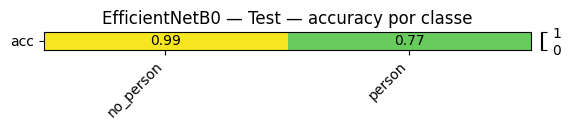

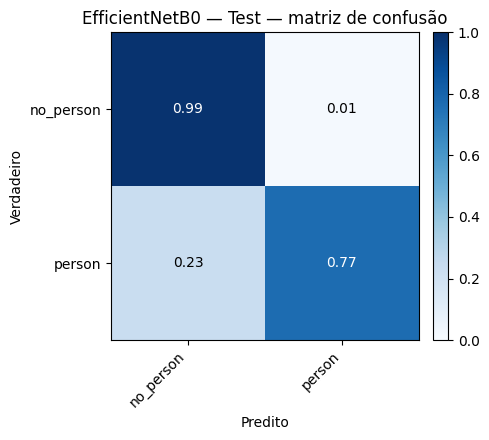

In [ ]:
# ---------- Evaluate EfficientNetB0 on test set ----------
m_eff_test, cm_eff_test = evaluate_model(effnet_model, test_ds, class_names, "EfficientNetB0 — Test")

In [ ]:
# ---------- Save EfficientNetB0 ----------
effb0_keras_path, effb0_keras_model = save_best_as_keras(
    build_efficientnetb0,
    effnet_results,
    filename="EfficientNetB0_WakeVision.keras",
)
print(f"\nFinal results EfficientNetB0: {effnet_results}")

---

# MCUNet — Wake Vision

Same training protocol (head → fine-tune) applied to **MCUNet** (MIT HAN Lab).

We use the official repository `third_party/mcunet-official` with ImageNet pre-trained models (PyTorch).
Workflow:
1. Load the pre-trained PyTorch model (`mcunet-in4`, 512KB SRAM / 2MB Flash)
2. Convert weights to Keras (PyTorch → Keras)
3. Perform fine-tuning on Wake Vision

> MCUNet uses ImageNet normalization `(x/255 - mean) / std`, implemented via custom layer `ImageNetNormalization`.

In [ ]:
import sys
import json
import torch
import numpy as np
from pathlib import Path
from tensorflow.keras import layers

# Adds the official MCUNet path to the path
MCUNET_OFFICIAL_PATH = Path("third_party/mcunet-official")
if str(MCUNET_OFFICIAL_PATH) not in sys.path:
    sys.path.insert(0, str(MCUNET_OFFICIAL_PATH))

from mcunet.model_zoo import build_model as build_mcunet_pytorch, net_id_list

# =====================================================================
# Custom ImageNet normalization layer (registered for serialization)
# =====================================================================
@tf.keras.utils.register_keras_serializable(package="MCUNet")
class ImageNetNormalization(layers.Layer):
    """ImageNet normalization: (x/255 - mean) / std"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
        self.std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

    def call(self, x):
        x = x / 255.0
        return (x - self.mean) / self.std

    def get_config(self):
        return super().get_config()

print("=" * 70)
print("MCUNet (official) — available models:")
print("=" * 70)
for net_id in net_id_list:
    print(f"  - {net_id}")

# =====================================================================
# MCUNet model choice
# =====================================================================
# ImageNet: mcunet-in0 (10fps), mcunet-in1 (5fps), mcunet-in2, mcunet-in3, mcunet-in4
# VWW:      mcunet-vww0 (10fps), mcunet-vww1 (5fps), mcunet-vww2 (320KB/1MB)
MCUNET_NET_ID = "mcunet-in4"  # 512KB SRAM, 2MB Flash — largest ImageNet model

print(f"\nLoading model: {MCUNET_NET_ID}")
pt_model, resolution, description = build_mcunet_pytorch(MCUNET_NET_ID, pretrained=True)
print(f"Native resolution: {resolution}x{resolution}")
print(f"Description: {description}")
pt_model.eval()

total_params = sum(p.numel() for p in pt_model.parameters())
print(f"Total parameters (PyTorch): {total_params:,}")

MCUNet (official) — available models:
  - mcunet-in0
  - mcunet-in1
  - mcunet-in2
  - mcunet-in3
  - mcunet-in4
  - mbv2-w0.35
  - proxyless-w0.3
  - mcunet-vww0
  - mcunet-vww1
  - mcunet-vww2
  - person-det

Loading model: mcunet-in4
Native resolution: 160x160
Description: MCUNet model that fits 512KB SRAM and 2MB Flash (ImageNet)
Total parameters (PyTorch): 1,732,640


In [ ]:
def build_mcunet_official(
    num_classes: int = NUM_CLASSES,
    dropout: float = 0.2,
    net_id: str = MCUNET_NET_ID,
):
    """
    Build a Keras model from the official MCUNet architecture.

    Load ImageNet pre-trained PyTorch weights and convert to Keras.
    Returns (full_model, backbone) for train_head_and_finetune.
    """
    # Load PyTorch model with pre-trained weights
    pt_model, resolution, _ = build_mcunet_pytorch(net_id, pretrained=True)
    pt_model.eval()
    pt_state = pt_model.state_dict()

    # Read network config
    net_config = pt_model.config

    # BatchNorm parameters
    bn_momentum = 0.9  # Keras default (PyTorch usa 0.1, que é 1-0.9)
    bn_eps = 1e-5

    # ========== KERAS MODEL CONSTRUCTION ==========
    preprocess = ImageNetNormalization(name="preprocess_mcunet_official")
    inputs, x = make_common_stem(preprocess)

    # Activation helper
    def _act(x, act_name, name):
        if act_name in (None, "none"):
            return x
        if act_name == "relu6":
            return layers.ReLU(max_value=6.0, name=name)(x)
        if act_name == "relu":
            return layers.ReLU(name=name)(x)
        return x

    # First conv
    first_conv_cfg = net_config.get("first_conv", {})
    out_ch = first_conv_cfg.get("out_channels", 32)
    ks = first_conv_cfg.get("kernel_size", 3)
    stride = first_conv_cfg.get("stride", 2)
    act = first_conv_cfg.get("act_func", "relu6")

    x = layers.Conv2D(out_ch, ks, strides=stride, padding="same", use_bias=False,
                      name="mcunet_off_first_conv")(x)
    x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps,
                                  name="mcunet_off_first_bn")(x)
    x = _act(x, act, name="mcunet_off_first_act")

    # MBConv blocks
    blocks_cfg = net_config.get("blocks", [])
    for i, block in enumerate(blocks_cfg):
        mic = block.get("mobile_inverted_conv", {})
        if not mic or mic.get("name") == "ZeroLayer":
            continue

        in_ch = mic.get("in_channels", 0)
        out_ch = mic.get("out_channels", 0)
        k = mic.get("kernel_size", 3)
        s = mic.get("stride", 1)
        expand_ratio = mic.get("expand_ratio", 1)
        mid_ch = mic.get("mid_channels")
        mid_ch = mid_ch if mid_ch else int(in_ch * expand_ratio)
        act = mic.get("act_func", "relu6")
        use_se = mic.get("use_se", False)

        shortcut_cfg = block.get("shortcut")
        has_shortcut = shortcut_cfg is not None and s == 1 and in_ch == out_ch
        x_in = x

        # Expand (1x1)
        if expand_ratio != 1:
            x = layers.Conv2D(mid_ch, 1, padding="same", use_bias=False,
                              name=f"mcunet_off_b{i}_expand")(x)
            x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps,
                                          name=f"mcunet_off_b{i}_expand_bn")(x)
            x = _act(x, act, name=f"mcunet_off_b{i}_expand_act")

        # Depthwise
        x = layers.DepthwiseConv2D(k, strides=s, padding="same", use_bias=False,
                                    name=f"mcunet_off_b{i}_dw")(x)
        x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps,
                                      name=f"mcunet_off_b{i}_dw_bn")(x)
        x = _act(x, act, name=f"mcunet_off_b{i}_dw_act")

        # SE block (Squeeze-and-Excitation) if present
        if use_se:
            se_ch = max(1, mid_ch // 4)
            se = layers.GlobalAveragePooling2D(keepdims=True, name=f"mcunet_off_b{i}_se_pool")(x)
            se = layers.Conv2D(se_ch, 1, activation="relu", name=f"mcunet_off_b{i}_se_reduce")(se)
            se = layers.Conv2D(mid_ch, 1, activation="sigmoid", name=f"mcunet_off_b{i}_se_expand")(se)
            x = layers.Multiply(name=f"mcunet_off_b{i}_se_mult")([x, se])

        # Project (1x1)
        x = layers.Conv2D(out_ch, 1, padding="same", use_bias=False,
                          name=f"mcunet_off_b{i}_project")(x)
        x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps,
                                      name=f"mcunet_off_b{i}_project_bn")(x)

        # Shortcut
        if has_shortcut:
            x = layers.Add(name=f"mcunet_off_b{i}_add")([x_in, x])

    # Feature conv (before the classifier)
    feature_mix_cfg = net_config.get("feature_mix_layer", {})
    if feature_mix_cfg and feature_mix_cfg.get("out_channels"):
        fm_out = feature_mix_cfg["out_channels"]
        x = layers.Conv2D(fm_out, 1, padding="same", use_bias=False,
                          name="mcunet_off_feature_mix")(x)
        x = layers.BatchNormalization(momentum=bn_momentum, epsilon=bn_eps,
                                      name="mcunet_off_feature_mix_bn")(x)
        x = _act(x, feature_mix_cfg.get("act_func", "relu6"), name="mcunet_off_feature_mix_act")

    x = layers.GlobalAveragePooling2D(name="mcunet_off_gap")(x)

    # Backbone (without classifier)
    backbone = tf.keras.Model(inputs, x, name="MCUNet_Official_Backbone")

    # Head Wake Vision
    x = layers.Dropout(dropout, name="mcunet_off_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="mcunet_off_classifier")(x)

    model = tf.keras.Model(inputs, outputs, name="MCUNet_Official_WakeVision")

    # ========== LOAD PYTORCH WEIGHTS ==========
    print("Converting PyTorch weights -> Keras...")
    loaded_count = 0

    for keras_layer in model.layers:
        layer_name = keras_layer.name
        weights_to_set = []

        try:
            # First conv
            if layer_name == "mcunet_off_first_conv":
                w = pt_state.get("first_conv.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0)]

            elif layer_name == "mcunet_off_first_bn":
                g = pt_state.get("first_conv.bn.weight")
                b = pt_state.get("first_conv.bn.bias")
                m = pt_state.get("first_conv.bn.running_mean")
                v = pt_state.get("first_conv.bn.running_var")
                if g is not None:
                    weights_to_set = [g.numpy(), b.numpy(), m.numpy(), v.numpy()]

            # Blocks - expand
            elif "_expand" in layer_name and "_bn" not in layer_name and "_act" not in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                w = pt_state.get(f"blocks.{idx}.mobile_inverted_conv.inverted_bottleneck.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0)]

            elif "_expand_bn" in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                base = f"blocks.{idx}.mobile_inverted_conv.inverted_bottleneck.bn"
                g = pt_state.get(f"{base}.weight")
                if g is not None:
                    weights_to_set = [g.numpy(),
                                      pt_state[f"{base}.bias"].numpy(),
                                      pt_state[f"{base}.running_mean"].numpy(),
                                      pt_state[f"{base}.running_var"].numpy()]

            # Blocks - depthwise
            elif "_dw" in layer_name and "_bn" not in layer_name and "_act" not in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                w = pt_state.get(f"blocks.{idx}.mobile_inverted_conv.depth_conv.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 0, 1)]

            elif "_dw_bn" in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                base = f"blocks.{idx}.mobile_inverted_conv.depth_conv.bn"
                g = pt_state.get(f"{base}.weight")
                if g is not None:
                    weights_to_set = [g.numpy(),
                                      pt_state[f"{base}.bias"].numpy(),
                                      pt_state[f"{base}.running_mean"].numpy(),
                                      pt_state[f"{base}.running_var"].numpy()]

            # Blocks - project
            elif "_project" in layer_name and "_bn" not in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                w = pt_state.get(f"blocks.{idx}.mobile_inverted_conv.point_linear.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0)]

            elif "_project_bn" in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                base = f"blocks.{idx}.mobile_inverted_conv.point_linear.bn"
                g = pt_state.get(f"{base}.weight")
                if g is not None:
                    weights_to_set = [g.numpy(),
                                      pt_state[f"{base}.bias"].numpy(),
                                      pt_state[f"{base}.running_mean"].numpy(),
                                      pt_state[f"{base}.running_var"].numpy()]

            # SE blocks
            elif "_se_reduce" in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                base = f"blocks.{idx}.mobile_inverted_conv.depth_conv.se.fc.reduce"
                w = pt_state.get(f"{base}.weight")
                b = pt_state.get(f"{base}.bias")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0), b.numpy()]

            elif "_se_expand" in layer_name:
                idx = layer_name.split("_b")[1].split("_")[0]
                base = f"blocks.{idx}.mobile_inverted_conv.depth_conv.se.fc.expand"
                w = pt_state.get(f"{base}.weight")
                b = pt_state.get(f"{base}.bias")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0), b.numpy()]

            # Feature mix layer
            elif layer_name == "mcunet_off_feature_mix":
                w = pt_state.get("feature_mix_layer.conv.weight")
                if w is not None:
                    weights_to_set = [w.numpy().transpose(2, 3, 1, 0)]

            elif layer_name == "mcunet_off_feature_mix_bn":
                base = "feature_mix_layer.bn"
                g = pt_state.get(f"{base}.weight")
                if g is not None:
                    weights_to_set = [g.numpy(),
                                      pt_state[f"{base}.bias"].numpy(),
                                      pt_state[f"{base}.running_mean"].numpy(),
                                      pt_state[f"{base}.running_var"].numpy()]

            if weights_to_set:
                keras_layer.set_weights(weights_to_set)
                loaded_count += 1

        except Exception as e:
            pass  # ignore unmapped layer errors

    print(f"✓ Weights loaded: {loaded_count} layers")

    # Freeze backbone to train the head only
    for layer in backbone.layers:
        layer.trainable = False

    return model, backbone


mcunet_model, mcunet_base = build_mcunet_official()
mcunet_model.summary()

Converting PyTorch weights -> Keras...
✓ Weights loaded: 102 layers


Model: "MCUNet_Official_WakeVision"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocess_mcunet_… │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (ImageNetNormaliza… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_first_c… │ (None, 112, 112,  │        864 │ preprocess_mcune… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_first_bn │ (None, 112, 112,  │        128 │ mcunet_off_first… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_first_a… │ (None, 112, 112,  │          0 │ mcunet_off_first… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b0_dw    │ (None, 112, 112,  │        288 │ mcunet_off_first… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b0_dw_bn │ (None, 112, 112,  │        128 │ mcunet_off_b0_dw… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b0_dw_a… │ (None, 112, 112,  │          0 │ mcunet_off_b0_dw… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b0_proj… │ (None, 112, 112,  │        512 │ mcunet_off_b0_dw… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b0_proj… │ (None, 112, 112,  │         64 │ mcunet_off_b0_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b1_expa… │ (None, 112, 112,  │        768 │ mcunet_off_b0_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b1_expa… │ (None, 112, 112,  │        192 │ mcunet_off_b1_ex… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b1_expa… │ (None, 112, 112,  │          0 │ mcunet_off_b1_ex… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b1_dw    │ (None, 56, 56,    │      2,352 │ mcunet_off_b1_ex… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b1_dw_bn │ (None, 56, 56,    │        192 │ mcunet_off_b1_dw… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b1_dw_a… │ (None, 56, 56,    │          0 │ mcunet_off_b1_dw… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mcunet_off_b1_proj… │ (None, 56, 56,    │      1,152 │ mcunet_off_b1_dw

 Total params: 1,433,690 (5.47 MB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 1,433,048 (5.47 MB)

In [ ]:
# ---------- Train MCUNet ----------
mcunet_results, history_mcunet_head, history_mcunet_ft = train_head_and_finetune(
    mcunet_model,
    mcunet_base,
    model_tag="MCUNet-WakeVision",
)


[MCUNet-WakeVision] Phase 1 — head training (40 epochs)
Epoch 1/40


2026-03-12 11:00:15.300502: I external/local_xla/xla/service/service.cc:163] XLA service 0x7efa80002da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-12 11:00:15.300543: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-03-12 11:00:15.356384: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-12 11:00:15.713856: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-12 11:00:18.732013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 11:00:18.811902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: 

19503/19504 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8776 - loss: 0.4114 - top2: 1.0000

2026-03-12 11:05:41.606029: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1547', 4 bytes spill stores, 4 bytes spill loads

2026-03-12 11:05:43.783741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 11:05:43.863094: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


19504/19504 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8776 - loss: 0.4114 - top2: 1.0000

2026-03-12 11:05:55.388128: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 11:05:55.467693: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


19504/19504 ━━━━━━━━━━━━━━━━━━━━ 344s 17ms/step - accuracy: 0.8827 - loss: 0.4026 - top2: 1.0000 - val_accuracy: 0.7995 - val_loss: 0.5218 - val_top2: 1.0000 - learning_rate: 0.0010
Epoch 2/40
19504/19504 ━━━━━━━━━━━━━━━━━━━━ 326s 17ms/step - accuracy: 0.8841 - loss: 0.3996 - top2: 1.0000 - val_accuracy: 0.7952 - val_loss: 0.5600 - val_top2: 1.0000 - learning_rate: 0.0010
Epoch 3/40
19504/19504 ━━━━━━━━━━━━━━━━━━━━ 327s 17ms/step - accuracy: 0.8845 - loss: 0.3993 - top2: 1.0000 - val_accuracy: 0.8064 - val_loss: 0.5085 - val_top2: 1.0000 - learning_rate: 0.0010
Epoch 4/40
19504/19504 ━━━━━━━━━━━━━━━━━━━━ 327s 17ms/step - accuracy: 0.8844 - loss: 0.3993 - top2: 1.0000 - val_accuracy: 0.8030 - val_loss: 0.5226 - val_top2: 1.0000 - learning_rate: 0.0010
Epoch 5/40
19504/19504 ━━━━━━━━━━━━━━━━━━━━ 327s 17ms/step - accuracy: 0.8843 - loss: 0.3993 - top2: 1.0000 - val_accuracy: 0.8032 - val_loss: 0.5233 - val_top2: 1.0000 - learning_rate: 0.0010
Epoch 6/40
19503/19504 ━━━━━━━━━━━━━━━━━━━━ 0s

2026-03-12 13:06:53.590263: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 13:06:53.669735: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



[MCUNet-WakeVision] Test acc (best weights): 0.8126 | top2: 1.0000 | loss: 0.4950


2026-03-12 13:06:55.259001: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-03-12 13:06:55.259017: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6434129995380221813
.../epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
# ---------- Load saved MCUNet (without retraining) ----------
mcunet_model = tf.keras.models.load_model(
    str(KERAS_MODELS_DIR / "MCUNet_WakeVision.keras"),
    custom_objects={"ImageNetNormalization": ImageNetNormalization},
)
mcunet_model.summary()

ValueError: File not found: filepath=keras_models/MCUNet_WakeVision.keras. Please ensure the file is an accessible `.keras` zip file.

2026-03-12 13:36:20.994406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 13:36:21.074148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[MCUNet — Test] accuracy=0.8127 | macro_f1=0.8085 | weighted_f1=0.8085
   no_person: acc=0.961 f1=0.837 support=27881
      person: acc=0.665 f1=0.780 support=27881


2026-03-12 13:37:15.007186: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


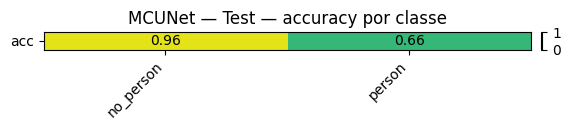

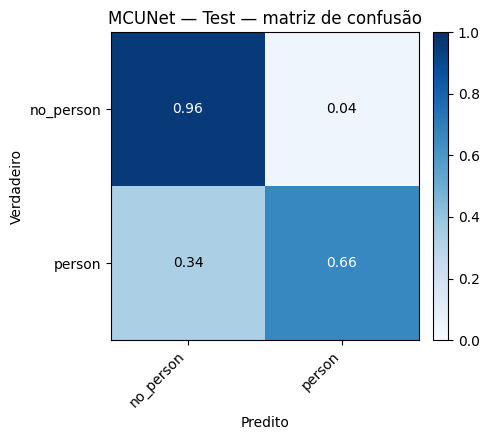

In [ ]:
# ---------- Evaluate MCUNet on test set ----------
m_mcunet_test, cm_mcunet_test = evaluate_model(mcunet_model, test_ds, class_names, "MCUNet — Test")

In [ ]:
# ---------- Save MCUNet ----------
mcunet_keras_path, mcunet_keras_model = save_best_as_keras(
    build_mcunet_official,
    mcunet_results,
    filename="MCUNet_WakeVision.keras",
)
print(f"\nFinal results MCUNet: {mcunet_results}")

Converting PyTorch weights -> Keras...
✓ Weights loaded: 102 layers
Model saved at: ./MCUNet_WakeVision.keras

Results finais MCUNet: {'test_acc_head': nan, 'test_loss_head': nan, 'test_acc_finetune': 0.8126322627067566, 'test_loss_finetune': 0.4949713349342346, 'test_top2': 1.0, 'best_weights': 'checkpoints/MCUNet-WakeVision_best.weights.h5'}
